In [1]:
import numpy as np
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.cm as cm
%config InlineBackend.figure_format = 'svg'

In [2]:
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({'lines.linewidth': 2})

# EH Self Acceleration In Uniform Electric Field

In [22]:
L = 60 * np.pi
nx = 4000
dx = L / (nx - 1)

vmax_e = 10  # 速度最大值
nv_e = 2000
dv_e = 2 * vmax_e / (nv_e - 1)

vmax_i = 0.52185  # 速度最大值
nv_i = 2000
dv_i = 2 * vmax_i / (nv_i - 1)

x = np.linspace(0, L, num=nx, endpoint=True)
ve = np.linspace(-vmax_e, vmax_e, num=nv_e, endpoint=True)
vi = np.linspace(-vmax_i, vmax_i, num=nv_i, endpoint=True)
Ve, Xe = np.meshgrid(ve, x)
Vi, Xi = np.meshgrid(vi, x)

psi = 0.1
delta = 5
Ea_s = 5
Ea_e = 305

dt = 0.05
max_steps = 20000
data_steps = int(max_steps / 1)
data_num = int(max_steps / data_steps) + 1

path1 = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\uniformE_E00004"
path2 = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\uniformE_E00008"
path3 = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\uniformE_E00012"
print(data_num)
print("real time = ", max_steps * dt)

2
real time =  1000.0


In [23]:
fe0 = np.loadtxt(os.path.join(path1,"fe0"))
fe1_final = np.loadtxt(os.path.join(path1,"fe1"))
fe2_final = np.loadtxt(os.path.join(path2,"fe5"))
fe3_final = np.loadtxt(os.path.join(path3,"fe1"))

In [24]:
lve = np.linspace(fe0.min(),fe0.max(),num=25)

C:\Users\RGuo\AppData\Local\Temp\ipykernel_10420\3124957226.py:8: UserWarning: Rasterization of '<matplotlib.contour.QuadContourSet object at 0x0000022E26A8B990>' will be ignored
  ax1cmp.set_rasterized(True)
C:\Users\RGuo\AppData\Local\Temp\ipykernel_10420\3124957226.py:13: UserWarning: Rasterization of '<matplotlib.contour.QuadContourSet object at 0x0000022E26A2A790>' will be ignored
  ax2cmp.set_rasterized(True)
C:\Users\RGuo\AppData\Local\Temp\ipykernel_10420\3124957226.py:18: UserWarning: Rasterization of '<matplotlib.contour.QuadContourSet object at 0x0000022E5D1C5ED0>' will be ignored
  ax3cmp.set_rasterized(True)


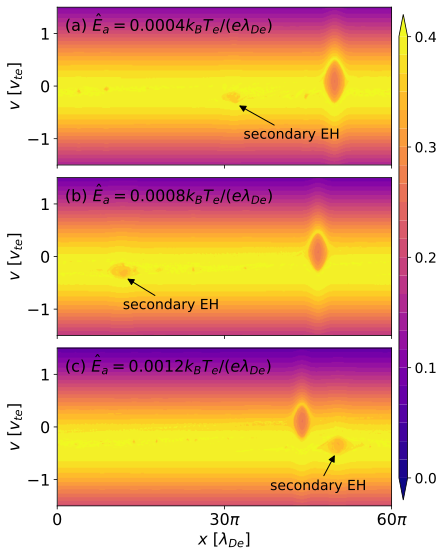

In [ ]:
x_ticks=[0, 15*np.pi, 30*np.pi, 45*np.pi, 60*np.pi]

fig,(ax1,ax2,ax3) = plt.subplots(figsize=(6, 9),ncols=1,nrows=3, sharex=True)

ax1cmp = ax1.contourf(Xe, Ve, fe1_final, levels=lve,extend='both',cmap=cm.plasma)
ax1.set_ylabel(r'$v~[v_{te}]$')
ax1.set_ylim(-1.5,1.5)
ax1cmp.set_rasterized(True)

ax2cmp = ax2.contourf(Xe, Ve, fe2_final, levels=lve,extend='both',cmap=cm.plasma)
ax2.set_ylabel(r'$v~[v_{te}]$')
ax2.set_ylim(-1.5,1.5)
ax2cmp.set_rasterized(True)

ax3cmp = ax3.contourf(Xe, Ve, fe3_final, levels=lve,extend='both',cmap=cm.plasma)
ax3.set_ylabel(r'$v~[v_{te}]$')
ax3.set_ylim(-1.5,1.5)
ax3cmp.set_rasterized(True)

ax3.set_xlabel(r"$x~[\lambda_{De}]$")
ax3.set_xticks([0, 30*np.pi, 60*np.pi], ["0", r"$30\pi$", r"$60\pi$"])

ax1.text(0.023, 0.85, r'(a) $\hat{E}_a=0.0004 k_B T_e/(e\lambda_{De})$', transform=ax1.transAxes)
ax2.text(0.023, 0.85, r'(b) $\hat{E}_a=0.0008 k_B T_e/(e\lambda_{De})$', transform=ax2.transAxes)
ax3.text(0.023, 0.85, r'(c) $\hat{E}_a=0.0012 k_B T_e/(e\lambda_{De})$', transform=ax3.transAxes)

ax1.annotate("secondary EH", xy=(101.5,-0.35), xytext=(105,-1), arrowprops=dict(arrowstyle="-|>",color='black'), fontsize=14)
ax2.annotate("secondary EH", xy=(38.5,-0.4), xytext=(37,-1), arrowprops=dict(arrowstyle="-|>",color='black'), fontsize=14)
ax3.annotate("secondary EH", xy=(157,-0.5), xytext=(120,-1.2), arrowprops=dict(arrowstyle="-|>",color='black'), fontsize=14)

cax = fig.add_axes([0.917, 0.119, 0.02, 0.75])
cbar=fig.colorbar(ax1cmp, cax=cax, orientation='vertical',shrink=1.0,ticks=[0.0,0.1,0.2,0.3,0.4])
cbar.ax.tick_params(labelsize=14)

fig.subplots_adjust(wspace=0.4, hspace=0.08)
fig.align_ylabels()

# plt.savefig("fig7_fe_final_uniformE_com.pdf", bbox_inches='tight', dpi=600)
plt.show()